# Multiclass and Multilabel Classification

Up until this point, we have lived in a binary world. Every algorithm we have built answered a simple "Yes or No" question: Fraud or Legitimate? Churn or Active? Premium or Standard?

But the enterprise world is rarely binary. If you are building a routing algorithm for a global customer support center, an incoming ticket doesn't just route to "Support" or "Not Support." It must be routed to "Billing," "Tech Support," "Returns," *or* "Sales." Furthermore, a ticket might need to be tagged as "Urgent," "Hardware Issue," *and* "Enterprise Client" all at the same time.

In this lesson, we break past the binary barrier and explore the complex mathematics of **Multiclass** and **Multilabel** learning.

Though they sound similar, Multiclass and Multilabel are fundamentally different mathematical formulations. Mixing them up is a common, catastrophic error made by junior data scientists. 

Let's set up our Python environment to dissect the difference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ N-Dimensional Classification Environment Ready.")

✅ N-Dimensional Classification Environment Ready.


# 1. Multiclass Classification (Mutually Exclusive)

**Multiclass Classification** is used when an observation belongs to *exactly one* category out of three or more possibilities. 
$$y \in \{0, 1, 2, \dots, K\}$$
*(Example: An animal is either a Dog, a Cat, or a Bird. It cannot be both a Dog and a Bird.)*

Some algorithms, like Decision Trees and Random Forests, handle Multiclass natively. Their math effortlessly adapts to splitting into 3 or 4 buckets. But binary algorithms (like Support Vector Machines and Logistic Regression) require specialized mathematical strategies to scale up.

### Strategy A: One-vs-Rest (OvR)
To classify 3 classes (A, B, C) using a binary algorithm, the OvR strategy builds **3 separate binary models**:
1.  Model 1: Is it **A** vs. **Not A** (B/C)?
2.  Model 2: Is it **B** vs. **Not B** (A/C)?
3.  Model 3: Is it **C** vs. **Not C** (A/B)?

When a new data point arrives, all 3 models make a prediction. The model that outputs the highest mathematical confidence (or probability) wins and dictates the final class.
*Total models trained: $K$*

### Strategy B: One-vs-One (OvO)
The OvO strategy pits every single class against every other class in a head-to-head duel. 
1.  Model 1: A vs. B (Ignores C)
2.  Model 2: A vs. C (Ignores B)
3.  Model 3: B vs. C (Ignores A)

When a new point arrives, every model casts a vote. The class with the most votes wins. 
*Total models trained: $\frac{K(K-1)}{2}$* *(Note: If you have 100 classes, OvO requires training 4,950 separate models! It is extremely computationally expensive but sometimes necessary for algorithms like SVMs that scale poorly with dataset size).*

# 2. Visualizing Multiclass Boundaries

Let's simulate a 3-class dataset and visualize how Logistic Regression carves the 2D space into three distinct, mathematically rigorous territories using the "Softmax" formulation (the modern, generalized version of Logistic Regression).

/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


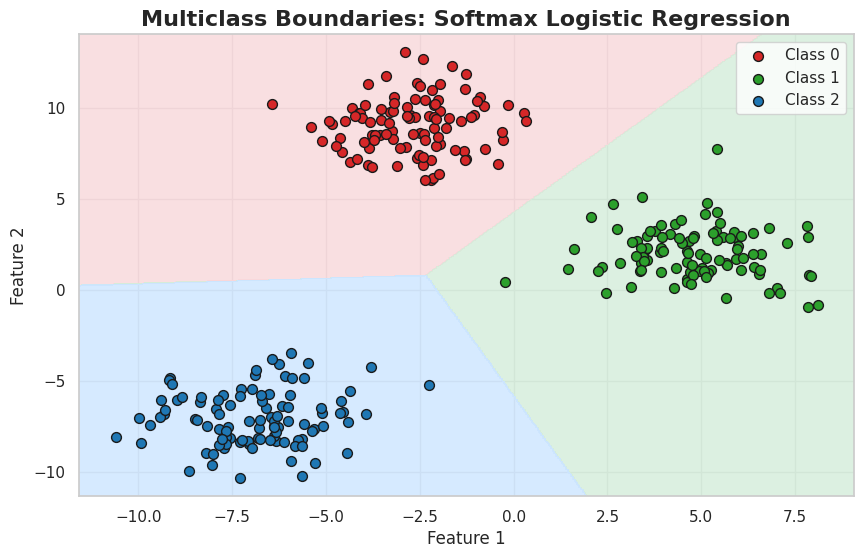

In [2]:
# 1. Simulate 3 distinct classes
X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=1.5)

# 2. Train a Multinomial Logistic Regression model (Native Multiclass via Softmax)
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs')
clf.fit(X, y)

# 3. Create a meshgrid to visualize the boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Matplotlib Visualization
plt.figure(figsize=(10, 6))

# We use a 3-color palette for the 3 distinct classes
cmap_light = ListedColormap(['#f8d7da', '#d4edda', '#cce5ff'])
cmap_bold = ['#d62728', '#2ca02c', '#1f77b4']

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Plot the raw data points
for i, color in zip([0, 1, 2], cmap_bold):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, edgecolor='k', s=50, label=f'Class {i}')

plt.title("Multiclass Boundaries: Softmax Logistic Regression", fontsize=16, fontweight='bold')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

*(Insight: Notice how the three territories intersect in the center to form a "Y" shape. The algorithm mathematically balanced three competing linear equations simultaneously to divide the space!)*

# 3. The Math of Competition: The Softmax Function

How did the Logistic Regression above actually output probabilities for 3 classes? In Lesson 04, we used the Sigmoid function to squash a single linear equation into a $0-1$ probability. 

For Multiclass, we upgrade the Sigmoid to the **Softmax Function**. 
If our model outputs a raw, unnormalized score (called a "Logit") for each of the $K$ classes, the Softmax function normalizes them into a probability distribution that mathematically guarantees they sum to exactly $1.0$.

$$P(y=j \mid x) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}$$

* $z_j$ is the raw linear score for class $j$.
* The denominator sums the exponentiated scores of all classes.
* **Intuition:** Softmax forces **competition**. If the probability of Class A goes up, the math dictates that the probabilities of Class B and C *must* go down to keep the total sum at 1.0.

# 4. Multilabel Classification (Non-Exclusive)

**Multilabel Classification** is used when an observation can belong to *zero, one, or multiple* categories simultaneously. 
$$y \in \{0, 1\}^K$$
*(Example: A movie can be tagged as Action AND Comedy AND Sci-Fi. Labeling it "Action" does not reduce the probability of it being a "Comedy".)*

Because the classes do not compete, **we cannot use the Softmax function.** If we use Softmax, an Action/Comedy movie will be split $50\% / 50\%$, and the model won't be confident in either!

### The Math of Independence (Multiple Sigmoids)
Instead of one Softmax function, we use **$K$ independent Sigmoid functions**. 
We build $K$ separate binary classifiers that have absolutely no mathematical knowledge of each other. 
1.  Model 1 outputs $P(\text{Action}) = 0.95$
2.  Model 2 outputs $P(\text{Comedy}) = 0.88$
3.  Model 3 outputs $P(\text{Romance}) = 0.05$

The sum of these probabilities is $1.88$, which is perfectly mathematically valid in Multilabel environments! We simply set a Decision Threshold (e.g., $0.5$) for each individual Sigmoid and tag the movie accordingly.

## Real-World Use Case or Analogy:
Think of the difference like **Sorting Produce** vs. **Tagging YouTube Videos**:

* **Multiclass (The Fruit Sorter)**: A conveyor belt drops a piece of fruit into a scanner. The fruit goes into exactly *one* bin. It is an Apple, an Orange, or a Banana. If the scanner calculates a 90% probability it is an Apple, the Softmax math forces the Orange and Banana probabilities to shrink down to 10%. They are competing for a single identity.
* **Multilabel (The Video Tagger)**: A creator uploads a video. They check boxes for "Gaming," "Tutorial," and "Funny." These tags are completely independent. Checking the "Gaming" box does not physically uncheck the "Funny" box. The algorithm evaluates every tag completely independently using individual Sigmoids.

---